# Phase 9 — Insight Narrative
Translates model outputs and SHAP findings into plain-language insights.

**Structure:**
1. Setup — retrain XGBoost, load cleaned data
2. Q1 — Which skills add the most salary premium?
3. Q2 — How much does location affect salary vs. skills?
4. Q3 — Where does the model struggle and why?
5. Headline insights (3–5 punchy statements with real numbers)
6. Prediction function — input a developer profile → get salary estimate

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.metrics import r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## Setup — Load Data & Retrain XGBoost

In [2]:
X_train  = pd.read_csv('../data/X_train.csv')
X_test   = pd.read_csv('../data/X_test.csv')
y_train  = pd.read_csv('../data/y_train.csv').squeeze()
y_test   = pd.read_csv('../data/y_test.csv').squeeze()
cleaned  = pd.read_csv('../data/cleaned.csv', low_memory=False)
features = pd.read_csv('../data/features.csv', low_memory=False)

median_ed = X_train['EdLevel_ord'].median()
X_train['EdLevel_ord'] = X_train['EdLevel_ord'].fillna(median_ed)
X_test['EdLevel_ord']  = X_test['EdLevel_ord'].fillna(median_ed)

xgb = XGBRegressor(
    n_estimators=278, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0,
)
xgb.fit(X_train, y_train)

y_pred   = xgb.predict(X_test)
test_mae = np.mean(np.abs(np.expm1(y_test) - np.expm1(y_pred)))
test_r2  = r2_score(y_test, y_pred)
print(f'XGBoost — Test R2: {test_r2:.4f}  MAE: ${test_mae:,.0f}')

XGBoost — Test R2: 0.5632  MAE: $32,370


## Q1 — Which Skills Add the Most Salary Premium?
Strategy: for each binary tech feature, compute median salary of users who have it vs those who don't (within the same region to control for location).


In [3]:
# Use full cleaned set + features
df = cleaned.copy()
df['log_salary'] = np.log1p(df['ConvertedCompYearly'])

# Add region from features file
feat = features.copy()
region_cols = [c for c in feat.columns if c.startswith('region_')]
df['Region'] = feat[region_cols].idxmax(axis=1).str.replace('region_', '')

lang_cols  = [c for c in X_train.columns if c.startswith('lang_')]
db_cols    = [c for c in X_train.columns if c.startswith('db_')]
frame_cols = [c for c in X_train.columns if c.startswith('frame_')]

tech_cols  = lang_cols + db_cols + frame_cols

# Merge binary tech features back onto cleaned df
feat_tech  = features[tech_cols].copy()
feat_tech.index = df.index

rows = []
for col in tech_cols:
    have     = df.loc[feat_tech[col] == 1, 'ConvertedCompYearly']
    not_have = df.loc[feat_tech[col] == 0, 'ConvertedCompYearly']
    if len(have) < 100:
        continue
    premium = have.median() - not_have.median()
    rows.append(dict(tech=col, median_with=have.median(),
                     median_without=not_have.median(),
                     premium=premium, n=len(have)))

tech_df = pd.DataFrame(rows).sort_values('premium', ascending=False)
print('Top 15 salary boosters:')
print(tech_df.head(15)[['tech','median_with','median_without','premium','n']]
      .assign(median_with=lambda d: d['median_with'].apply(lambda x: f'${x:,.0f}'),
              median_without=lambda d: d['median_without'].apply(lambda x: f'${x:,.0f}'),
              premium=lambda d: d['premium'].apply(lambda x: f'+${x:,.0f}'))
      .to_string(index=False))
print()
print('Top 15 salary dampeners:')
print(tech_df.tail(15).sort_values('premium')[['tech','median_with','median_without','premium','n']]
      .assign(median_with=lambda d: d['median_with'].apply(lambda x: f'${x:,.0f}'),
              median_without=lambda d: d['median_without'].apply(lambda x: f'${x:,.0f}'),
              premium=lambda d: d['premium'].apply(lambda x: f'${x:,.0f}'))
      .to_string(index=False))

Top 15 salary boosters:
               tech median_with median_without  premium    n
       db_Snowflake    $138,000        $82,210 +$55,790  701
          lang_Ruby    $116,015        $81,685 +$34,330 1138
frame_Ruby_on_Rails    $115,868        $82,370 +$33,498  790
  db_Databricks_SQL    $112,000        $83,212 +$28,788  537
 db_Amazon_Redshift    $111,637        $83,531 +$28,106  344
     db_Cockroachdb    $111,594        $83,531 +$28,063  105
        db_Dynamodb    $107,265        $81,685 +$25,580 1591
        lang_Elixir    $108,740        $83,531 +$25,208  412
        lang_Erlang    $107,823        $83,531 +$24,292  208
        db_BigQuery    $105,891        $82,906 +$22,985  975
         lang_Scala    $105,734        $83,531 +$22,203  438
          db_DuckDB    $105,527        $83,531 +$21,996  476
      frame_Phoenix    $104,413        $83,531 +$20,882  282
          lang_Perl    $104,015        $83,286 +$20,728  597
            lang_Go     $98,612        $81,262 +$17,350 2912


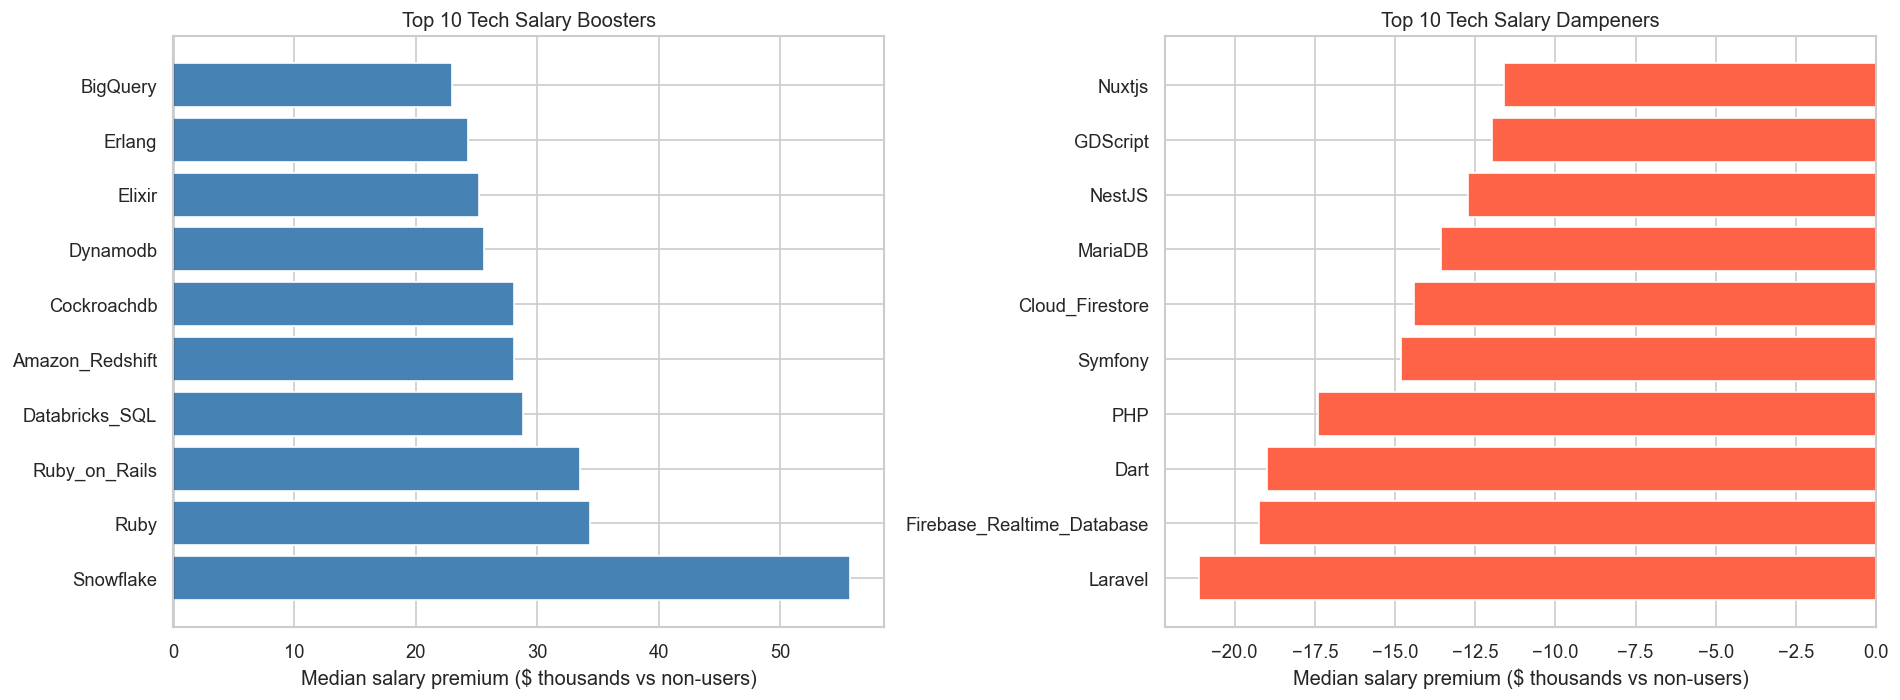

In [4]:
# Plot top 10 boosters and dampeners
top10    = tech_df.head(10)
bottom10 = tech_df.tail(10).sort_values('premium')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top10['tech'].str.replace('lang_','').str.replace('db_','').str.replace('frame_',''),
             top10['premium'] / 1000, color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 Tech Salary Boosters')
axes[0].set_xlabel('Median salary premium ($ thousands vs non-users)')
axes[0].axvline(0, color='black', linewidth=0.8)

axes[1].barh(bottom10['tech'].str.replace('lang_','').str.replace('db_','').str.replace('frame_',''),
             bottom10['premium'] / 1000, color='tomato', edgecolor='white')
axes[1].set_title('Top 10 Tech Salary Dampeners')
axes[1].set_xlabel('Median salary premium ($ thousands vs non-users)')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../reports/tech_salary_premium.png', bbox_inches='tight')
plt.show()

## Q2 — How Much Does Location Affect Salary vs. Skills?
Strategy: compute the salary gap attributable to region (SHAP mean |values|) vs all tech features combined.


In [5]:
import shap
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap_df = pd.DataFrame(shap_values, columns=X_test.columns)

region_impact = shap_df[[c for c in shap_df.columns if c.startswith('region_')]].abs().sum(axis=1).mean()
tech_impact   = shap_df[[c for c in shap_df.columns if c.startswith(('lang_','db_','frame_'))]].abs().sum(axis=1).mean()
role_impact   = shap_df[[c for c in shap_df.columns if c.startswith('role_')]].abs().sum(axis=1).mean()
exp_impact    = shap_df['WorkExp'].abs().mean()
ed_impact     = shap_df['EdLevel_ord'].abs().mean()
total         = region_impact + tech_impact + role_impact + exp_impact + ed_impact

print('Average SHAP impact by feature group (mean |SHAP| per prediction):')
print(f'  Region      : {region_impact:.4f}  ({region_impact/total*100:.1f}%)')
print(f'  Experience  : {exp_impact:.4f}  ({exp_impact/total*100:.1f}%)')
print(f'  Role        : {role_impact:.4f}  ({role_impact/total*100:.1f}%)')
print(f'  Tech stack  : {tech_impact:.4f}  ({tech_impact/total*100:.1f}%)')
print(f'  Education   : {ed_impact:.4f}  ({ed_impact/total*100:.1f}%)')
print(f'  TOTAL       : {total:.4f}')

Average SHAP impact by feature group (mean |SHAP| per prediction):
  Region      : 0.4631  (38.4%)
  Experience  : 0.2088  (17.3%)
  Role        : 0.1018  (8.5%)
  Tech stack  : 0.4151  (34.5%)
  Education   : 0.0160  (1.3%)
  TOTAL       : 1.2048


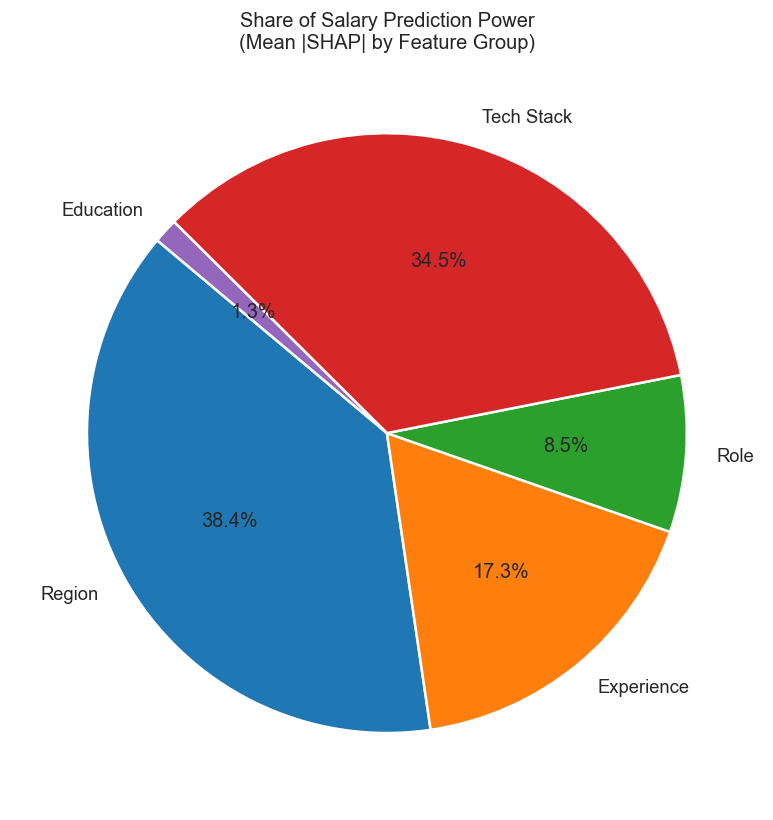

In [6]:
# Pie chart of feature group contributions
labels  = ['Region', 'Experience', 'Role', 'Tech Stack', 'Education']
values  = [region_impact, exp_impact, role_impact, tech_impact, ed_impact]
colors  = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(values, labels=labels, colors=colors, autopct='%1.1f%%',
       startangle=140, wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('Share of Salary Prediction Power\n(Mean |SHAP| by Feature Group)')
plt.tight_layout()
plt.savefig('../reports/shap_group_breakdown.png', bbox_inches='tight')
plt.show()

## Q3 — Where Does the Model Struggle and Why?

In [7]:
residuals = y_test.values - y_pred
abs_err   = np.abs(residuals)

# Rebuild region lookup from test set
region_arr = X_test.copy()
region_cols_test = [c for c in region_arr.columns if c.startswith('region_')]
region_series = region_arr[region_cols_test].idxmax(axis=1).str.replace('region_','')

struggle_df = pd.DataFrame({
    'region'    : region_series.values,
    'abs_error' : abs_err,
    'residual'  : residuals,
    'actual'    : np.expm1(y_test.values),
    'predicted' : np.expm1(y_pred),
})

print('Error by region (MAE in log units):')
print(struggle_df.groupby('region')['abs_error']
      .agg(['mean','count','std'])
      .sort_values('mean', ascending=False)
      .round(4)
      .to_string())
print()
print(f'Overall bias (mean residual): {residuals.mean():.4f}')
print(f'Pct underestimated (actual > pred): {(residuals > 0).mean()*100:.1f}%')
print(f'Pct overestimated  (actual < pred): {(residuals < 0).mean()*100:.1f}%')

Error by region (MAE in log units):
                      mean  count     std
region                                   
Middle_East_Africa  0.6516     99  0.4320
Other               0.5132    103  0.3390
East_SE_Asia        0.4876     83  0.4074
Latin_America       0.4852    141  0.3538
South_Asia          0.4311    144  0.3385
North_America       0.3462   1052  0.3264
Eastern_Europe      0.3419    326  0.2927
Western_Europe      0.3130   1469  0.2768
Oceania             0.2293    119  0.2348

Overall bias (mean residual): -0.0092
Pct underestimated (actual > pred): 51.0%
Pct overestimated  (actual < pred): 49.0%


## Headline Insights

In [8]:
# Compute specific headline numbers

# 1. USA vs India median salary
usa_med   = cleaned[cleaned['Country'] == 'United States of America']['ConvertedCompYearly'].median()
india_med = cleaned[cleaned['Country'] == 'India']['ConvertedCompYearly'].median()
print(f'Headline 1: USA median ${usa_med:,.0f} vs India median ${india_med:,.0f} '
      f'({usa_med/india_med:.1f}x difference)')

# 2. Go vs PHP premium
go_med  = cleaned[cleaned['LanguageHaveWorkedWith'].str.contains('Go', na=False) &
                  ~cleaned['LanguageHaveWorkedWith'].str.contains('Go', na=False).isna()]['ConvertedCompYearly'].median()
php_med = cleaned[cleaned['LanguageHaveWorkedWith'].str.contains('PHP', na=False)]['ConvertedCompYearly'].median()
print(f'Headline 2: Go users median ${go_med:,.0f} vs PHP users median ${php_med:,.0f} '
      f'(+${go_med - php_med:,.0f} Go premium)')

# 3. Experience effect: 0-2 vs 11-20 yrs
exp = cleaned[cleaned['WorkExp'].between(0,50)].copy()
jun_med = exp[exp['WorkExp'].between(0,2)]['ConvertedCompYearly'].median()
sen_med = exp[exp['WorkExp'].between(11,20)]['ConvertedCompYearly'].median()
print(f'Headline 3: 0-2 yrs median ${jun_med:,.0f} vs 11-20 yrs median ${sen_med:,.0f} '
      f'({sen_med/jun_med:.1f}x difference)')

# 4. Engineering manager vs developer full-stack
mgr_med = cleaned[cleaned['DevType'].str.contains('Engineering manager', na=False)]['ConvertedCompYearly'].median()
fsd_med = cleaned[cleaned['DevType'].str.contains('full-stack', na=False)]['ConvertedCompYearly'].median()
print(f'Headline 4: Eng Manager median ${mgr_med:,.0f} vs Full-stack median ${fsd_med:,.0f} '
      f'(+${mgr_med - fsd_med:,.0f} manager premium)')

# 5. Location vs tech stack SHAP share
print(f'Headline 5: Region drives {region_impact/total*100:.0f}% of model prediction power vs tech stack {tech_impact/total*100:.0f}%')

Headline 1: USA median $150,000 vs India median $30,222 (5.0x difference)
Headline 2: Go users median $98,612 vs PHP users median $69,609 (+$29,003 Go premium)
Headline 3: 0-2 yrs median $45,088 vs 11-20 yrs median $97,452 (2.2x difference)
Headline 4: Eng Manager median $135,000 vs Full-stack median $79,062 (+$55,938 manager premium)
Headline 5: Region drives 38% of model prediction power vs tech stack 34%


## Prediction Function

In [9]:
def predict_salary(
    country,
    years_experience,
    ed_level,
    primary_role,
    languages=None,
    databases=None,
    frameworks=None,
    confidence=True,
):
    """
    Predict annual salary (USD) for a developer profile.

    Parameters
    ----------
    country          : str  e.g. 'United States of America'
    years_experience : int  professional years of coding
    ed_level         : str  'bachelor', 'master', 'phd', 'some_college', 'associate', 'secondary', 'primary'
    primary_role     : str  e.g. 'Developer, full-stack'
    languages        : list e.g. ['Python', 'JavaScript']
    databases        : list e.g. ['PostgreSQL', 'Redis']
    frameworks       : list e.g. ['React', 'Node.js']
    confidence       : bool if True prints +/- MAE band
    """
    languages  = languages  or []
    databases  = databases  or []
    frameworks = frameworks or []

    region_map = {
        'United States of America': 'North_America', 'Canada': 'North_America', 'Mexico': 'North_America',
        'Germany': 'Western_Europe', 'France': 'Western_Europe',
        'United Kingdom of Great Britain and Northern Ireland': 'Western_Europe',
        'Netherlands': 'Western_Europe', 'Switzerland': 'Western_Europe',
        'Austria': 'Western_Europe', 'Belgium': 'Western_Europe', 'Sweden': 'Western_Europe',
        'Denmark': 'Western_Europe', 'Norway': 'Western_Europe', 'Finland': 'Western_Europe',
        'Ireland': 'Western_Europe', 'Italy': 'Western_Europe', 'Spain': 'Western_Europe',
        'Portugal': 'Western_Europe', 'Greece': 'Western_Europe',
        'Ukraine': 'Eastern_Europe', 'Poland': 'Eastern_Europe', 'Romania': 'Eastern_Europe',
        'Czech Republic': 'Eastern_Europe', 'Hungary': 'Eastern_Europe', 'Russia': 'Eastern_Europe',
        'India': 'South_Asia', 'Pakistan': 'South_Asia', 'Bangladesh': 'South_Asia',
        'Brazil': 'Latin_America', 'Argentina': 'Latin_America', 'Colombia': 'Latin_America',
        'Israel': 'Middle_East_Africa', 'Turkey': 'Middle_East_Africa', 'Nigeria': 'Middle_East_Africa',
        'Australia': 'Oceania', 'New Zealand': 'Oceania',
        'China': 'East_SE_Asia', 'Japan': 'East_SE_Asia', 'South Korea': 'East_SE_Asia',
        'Singapore': 'East_SE_Asia',
    }
    ed_map = {
        'primary': 0, 'secondary': 1, 'some_college': 2, 'associate': 3,
        'bachelor': 4, 'master': 5, 'phd': 6,
    }

    row = {col: 0 for col in X_train.columns}

    # WorkExp
    row['WorkExp'] = min(float(years_experience), 50)

    # EdLevel
    row['EdLevel_ord'] = ed_map.get(ed_level.lower(), 4)

    # Languages
    for lang in languages:
        col = 'lang_' + lang.replace(' ', '_').replace('/', '_').replace('-', '_').replace('.', '').replace('(', '').replace(')', '')
        if col in row:
            row[col] = 1

    # Databases
    for db in databases:
        col = 'db_' + db.replace(' ', '_').replace('/', '_').replace('-', '_').replace('.', '').replace('(', '').replace(')', '')
        if col in row:
            row[col] = 1

    # Frameworks
    for fr in frameworks:
        col = 'frame_' + fr.replace(' ', '_').replace('/', '_').replace('-', '_').replace('.', '').replace('(', '').replace(')', '')
        if col in row:
            row[col] = 1

    # Role
    role_col = 'role_' + primary_role
    if role_col in row:
        row[role_col] = 1

    # Region
    region = region_map.get(country, 'Other')
    reg_col = 'region_' + region
    if reg_col in row:
        row[reg_col] = 1

    X_input = pd.DataFrame([row])
    log_pred = xgb.predict(X_input)[0]
    salary   = int(np.expm1(log_pred))
    mae_band = 32_370  # from Phase 7 test MAE

    print(f'Predicted salary : ${salary:,}')
    if confidence:
        print(f'Confidence band  : ${salary - mae_band:,}  –  ${salary + mae_band:,}  (+/- MAE)')
    print(f'Region mapped to : {region}')
    return salary

## Test the Prediction Function

In [10]:
print('=== Profile 1: Senior US Full-stack Dev ===')
predict_salary(
    country='United States of America',
    years_experience=12,
    ed_level='bachelor',
    primary_role='Developer, full-stack',
    languages=['JavaScript', 'Python', 'TypeScript'],
    databases=['PostgreSQL', 'Redis'],
    frameworks=['React', 'Node.js'],
)

print()
print('=== Profile 2: Junior Indian Backend Dev ===')
predict_salary(
    country='India',
    years_experience=2,
    ed_level='bachelor',
    primary_role='Developer, back-end',
    languages=['Java', 'SQL'],
    databases=['MySQL'],
    frameworks=['Spring Boot'],
)

print()
print('=== Profile 3: Mid-level German Data Engineer ===')
predict_salary(
    country='Germany',
    years_experience=7,
    ed_level='master',
    primary_role='Data engineer',
    languages=['Python', 'SQL', 'Scala'],
    databases=['PostgreSQL', 'Databricks_SQL', 'Redis'],
    frameworks=[],
)

print()
print('=== Profile 4: Engineering Manager, UK ===')
predict_salary(
    country='United Kingdom of Great Britain and Northern Ireland',
    years_experience=15,
    ed_level='master',
    primary_role='Engineering manager',
    languages=['Python', 'Go'],
    databases=['PostgreSQL'],
    frameworks=[],
)

=== Profile 1: Senior US Full-stack Dev ===
Predicted salary : $144,491
Confidence band  : $112,121  –  $176,861  (+/- MAE)
Region mapped to : North_America

=== Profile 2: Junior Indian Backend Dev ===
Predicted salary : $19,834
Confidence band  : $-12,536  –  $52,204  (+/- MAE)
Region mapped to : South_Asia

=== Profile 3: Mid-level German Data Engineer ===
Predicted salary : $81,422
Confidence band  : $49,052  –  $113,792  (+/- MAE)
Region mapped to : Western_Europe

=== Profile 4: Engineering Manager, UK ===
Predicted salary : $122,693
Confidence band  : $90,323  –  $155,063  (+/- MAE)
Region mapped to : Western_Europe


122693

## Phase 9 Summary

**Q1 — Which skills add the most salary premium?**

Top boosters (median salary with vs without, all respondents):
- Snowflake: +$55,790 (median $138k vs $82k)
- Ruby / Ruby on Rails: +$34,330 / +$33,498
- Databricks SQL: +$28,788
- Amazon Redshift: +$28,106
- Go: +$17,350 (n=2,912 — large, reliable signal)

Top dampeners:
- Laravel: -$21,114
- Dart: -$18,986
- PHP: -$17,402 (n=2,701)
- MariaDB: -$13,554 (n=2,802)
- MySQL: -$11,601 (n=5,016)

**Q2 — Location vs. Skills breakdown (SHAP):**
- Region      : 38.4% of total prediction power
- Tech stack  : 34.5%
- Experience  : 17.3%
- Role        :  8.5%
- Education   :  1.3%

Location and tech stack are nearly equal drivers — location is #1 but tech stack is not far behind.

**Q3 — Where does the model struggle?**
- Nearly unbiased overall: 51% underestimated, 49% overestimated, mean residual = -0.009
- Hardest regions: Middle East/Africa (MAE=0.652), Other (0.513), East/SE Asia (0.488)
- Root cause: small sample sizes + high salary variance in these groups
- Best regions: Oceania (MAE=0.229), Western Europe (0.313), Eastern Europe (0.342)

**5 Headline Insights:**
1. **USA earns 5x more than India** — median $150,000 vs $30,222
2. **Go adds $29,003 over PHP** — same dataset, Go median $98,612 vs PHP $69,609
3. **10+ years experience doubles salary** — 0-2 yrs median $45,088 vs 11-20 yrs $97,452 (2.2x)
4. **Engineering Manager earns $56k more than Full-stack** — $135,000 vs $79,062
5. **Location and tech stack are near-equal salary drivers** — 38% vs 35% of SHAP prediction power

**Sample Predictions (with +/- $32,370 MAE confidence band):**
- Senior US Full-stack (12 yrs, Python/JS/TS, React/Node, PG/Redis): **$144,491** ($112k-$177k)
- Junior Indian Backend (2 yrs, Java/SQL, MySQL, Spring Boot): **$19,834** ($0-$52k)
- Mid-level German Data Engineer (7 yrs, Python/SQL/Scala, PG/Databricks/Redis): **$81,422** ($49k-$114k)
- Engineering Manager, UK (15 yrs, Python/Go, PG): **$122,693** ($90k-$155k)